In [1]:
#Anabela Petrushevikj
#D207
#Exploratory Analysis

In [3]:
#Import all packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [4]:
df = pd.read_csv('medical_clean_D207.csv')

In [103]:
#Getting information about the dataset and it's variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [104]:
# Separate the Initial_days data for patients who were readmitted and those who were not
initial_days_readmitted = df[df['ReAdmis'] == 'Yes']['Initial_days']
initial_days_not_readmitted = df[df['ReAdmis'] == 'No']['Initial_days']

# Perform an independent t-test
t_stat_initial_days, p_value = stats.ttest_ind(initial_days_readmitted, initial_days_not_readmitted, equal_var=False)

print('T-test statistic:',t_stat_initial_days)
print('P-value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('There is a significant relationship between readmission of patients and the initial number of days that patients were hospitalized.')
else:
    print('There is not a significant relationship between readmission of patients and the initial number of days that patients were hospitalized.')


T-test statistic: 203.00996600080393
P-value: 0.0
There is a significant relationship between readmission of patients and the initial number of days that patients were hospitalized.


In [105]:
#Univariate Statistics for Initial_days variable
summary_initial_days = df['Initial_days'].describe()
print('Summary for Initial_days:', summary_initial_days)

Summary for Initial_days: count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64


In [106]:
#Univariate Statistics for Age variable
summary_age = df['Age'].describe()
print('Summary for Age:', summary_age)

Summary for Age: count    10000.000000
mean        53.511700
std         20.638538
min         18.000000
25%         36.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64


In [107]:
#Univariate Statistics for ReAdmis variable
readmission = df['ReAdmis'].value_counts(normalize = True).sort_values(ascending = False)
print('Relative frequency for Readmission:', readmission)

Relative frequency for Readmission: ReAdmis
No     0.6331
Yes    0.3669
Name: proportion, dtype: float64


In [108]:
#Univariate Statistics for Complication_Risk variable
complication_risk = df['Complication_risk'].value_counts(normalize = True).sort_values(ascending = False)
print('Relative frequency for complication risk:', complication_risk)

Relative frequency for complication risk: Complication_risk
Medium    0.4517
High      0.3358
Low       0.2125
Name: proportion, dtype: float64


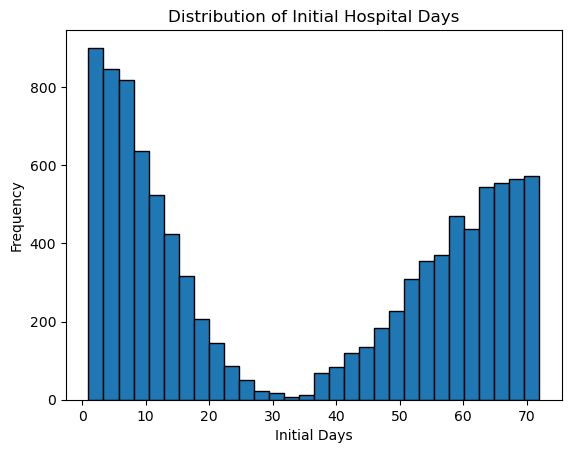

In [109]:
# Continuous variable 1: Distribution of Initial_days
plt.hist(df['Initial_days'], bins=30, edgecolor='black')
plt.title('Distribution of Initial Hospital Days')
plt.xlabel('Initial Days')
plt.ylabel('Frequency')
plt.show()


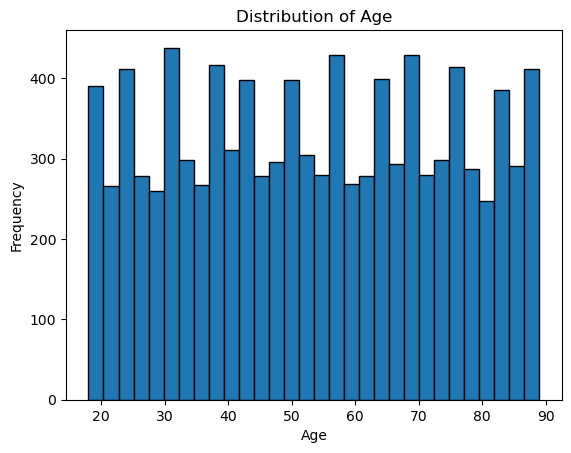

In [110]:
# Continuous variable 2: Distribution of Age
plt.hist(df['Age'], bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

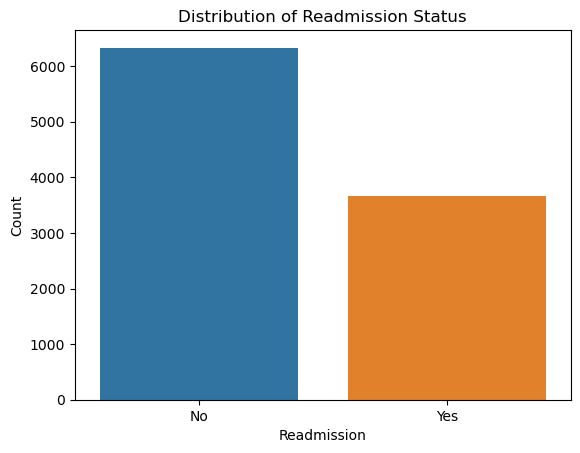

In [111]:
# Categorical variable 1: Distribution of ReAdmis
sns.countplot(x='ReAdmis', hue= None, data=df)
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmission')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Count')

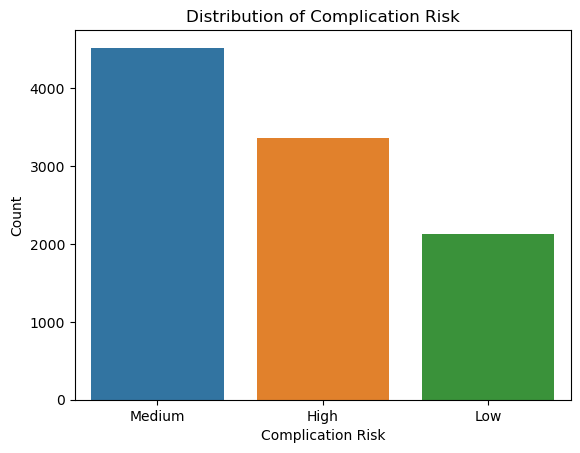

In [112]:
# Categorical variable 2: Distribution of Complication Risk
sns.countplot(x='Complication_risk', hue= None, data=df)
plt.title('Distribution of Complication Risk')
plt.xlabel('Complication Risk')
plt.ylabel('Count')

In [113]:
#Bivariate analysis for Initial_days and Age variables
pearson, _ = stats.pearsonr(df.Initial_days, df.Age)
print("Pearson correlation coefficient:")
print(pearson)

Pearson correlation coefficient:
0.016264289866716027


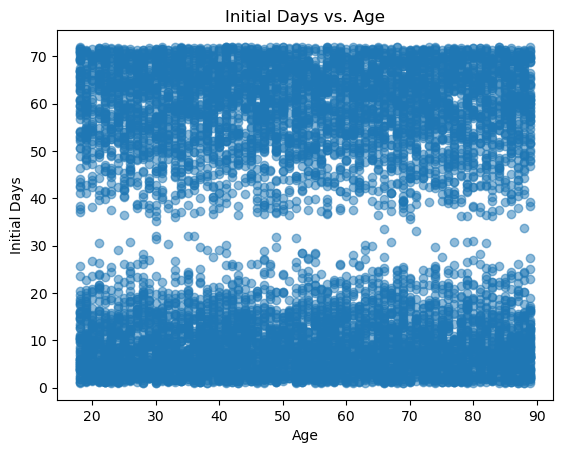

In [114]:
# Bivariate plot 1: Scatter plot of Initial Days vs. Age
plt.scatter(df['Age'], df['Initial_days'], alpha=0.5)
plt.title('Initial Days vs. Age')
plt.xlabel('Age')
plt.ylabel('Initial Days')
plt.show()


In [115]:
#Bivariate analysis for Readmission and Complication Risk
#Contingency table
contingency_table = pd.crosstab(df['ReAdmis'], df['Complication_risk'])

# Perform the chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Calculate Cramér's V
# Total number of observations
n = contingency_table.sum().sum()
# Minimum dimension of the contingency table minus 1
min_dim = min(contingency_table.shape) - 1  
cramers_v = np.sqrt(chi2 / (n * min_dim))
print('Chi squared test:', chi2)
print('P-value for chi squared test:', p)
print('Cramers_v value:',cramers_v)

Chi squared test: 0.15902193516217972
P-value for chi squared test: 0.923567890607327
Cramers_v value: 0.003987755448396751


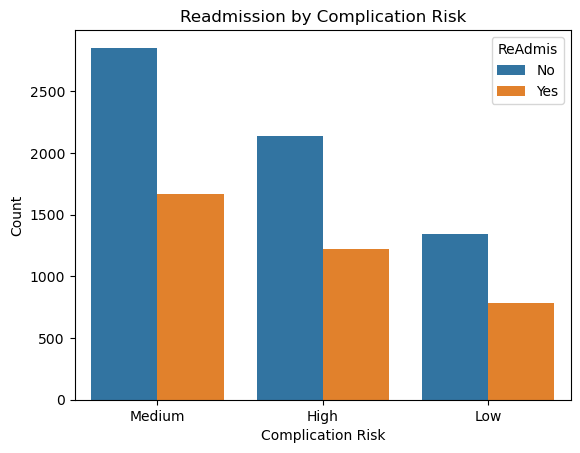

In [116]:
# Bivariate plot 2: Bar plot of Readmission by Complication Risk
sns.countplot(x='Complication_risk', hue='ReAdmis', data=df)
plt.title('Readmission by Complication Risk')
plt.xlabel('Complication Risk')
plt.ylabel('Count')
plt.show()